## DS2500 Final Project
#### Ethan McGeever & Matthew Lam
######  Deahan Yu Section 1 

Research Question: *“During the 2008 crisis, the 2020 COVID shock, and the 2021-2023 inflation period, which indicators moved first and had the strongest relationship with delinquencies?”*

The structure of our analysis is as follows: 
1) Imports and Aggregation
2) Data Transformations & Lag Effects
3) EDA -- Summary Statistics and Basic Correlation Analysis
4) Advanced Correlation Analysis
5) Findings
6) Conclusion

## Imports & Aggregation

In [266]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [267]:
# Github urls for datasets
pce_health_care_url = 'https://raw.githubusercontent.com/emcgeever-husky/Lam-McGeever-2500/17049f085df3b6d5aa927ff99f2829e8fbe70a8a/Datasets/DHLCRG3Q086SBEA.csv'
pce_food_url = 'https://raw.githubusercontent.com/emcgeever-husky/Lam-McGeever-2500/4d82c3341b7c1afd971edbc68a52aeafe1707c6d/Datasets/DFXARG3M086SBEA.csv'
pce_energy_url = 'https://raw.githubusercontent.com/emcgeever-husky/Lam-McGeever-2500/48732e2febbfa7f766ab4075ef23ed06cf9346be/Datasets/DNRGRG3M086SBEA.csv'
pce_core_url = 'https://raw.githubusercontent.com/emcgeever-husky/Lam-McGeever-2500/16ed26f9fa59b72f00c8a470e3de2a9b44dec472/Datasets/PCEPILFE.csv'
u6_url = 'https://raw.githubusercontent.com/emcgeever-husky/Lam-McGeever-2500/48732e2febbfa7f766ab4075ef23ed06cf9346be/Datasets/U6RATE.csv'
ccard_dr_url = 'https://raw.githubusercontent.com/emcgeever-husky/Lam-McGeever-2500/48732e2febbfa7f766ab4075ef23ed06cf9346be/Datasets/DRCCLACBS.csv'
csm_loan_dr_url = 'https://raw.githubusercontent.com/emcgeever-husky/Lam-McGeever-2500/48732e2febbfa7f766ab4075ef23ed06cf9346be/Datasets/DRCLACBS.csv'
mtg_dr_url = 'https://raw.githubusercontent.com/emcgeever-husky/Lam-McGeever-2500/48732e2febbfa7f766ab4075ef23ed06cf9346be/Datasets/DRSFRMACBS.csv'
permit_url = 'https://raw.githubusercontent.com/emcgeever-husky/Lam-McGeever-2500/refs/heads/main/Datasets/PERMIT.csv'
vix_url = 'https://raw.githubusercontent.com/emcgeever-husky/Lam-McGeever-2500/refs/heads/main/Datasets/VIXCLS.csv'

# Dataframes
indicators_df = pd.read_csv(pce_health_care_url) + pd.read_csv(pce_food_url) + pd.read_csv(pce_core_url) + pd.read_csv(pce_energy_url) + pd.read_csv(u6_url) + pd.read_csv(permit_url) + pd.read_csv(vix_url)
delinquency_rates_df = pd.read_csv(ccard_dr_url) + pd.read_csv(csm_loan_dr_url) + pd.read_csv(mtg_dr_url)

#### FRED dataset helper function

In [268]:
def load_fred(url, name):
    df = pd.read_csv(url, parse_dates=['observation_date'])
    df = df.rename(columns={df.columns[1]: name, 'observation_date': 'date'})
    return df.set_index('date')

#### Loading the Data

In [269]:
pce_health = load_fred(pce_health_care_url, 'pce_health')
pce_food = load_fred(pce_food_url, 'pce_food')
pce_energy = load_fred(pce_energy_url, 'pce_energy')
pce_core = load_fred(pce_core_url, 'pce_core')
u_6 = load_fred(u6_url, 'U6')
permit = load_fred(permit_url, 'permit')
vix = load_fred(vix_url, 'vix')

ccard_dr = load_fred(ccard_dr_url, 'ccard_dr')
csm_loan_dr = load_fred(csm_loan_dr_url, 'csm_loan_dr')
mtg_dr = load_fred(mtg_dr_url, 'mtg_dr')

#### Convert Monthly Datasets to Quarterly (Using Last Month of Q)

In [270]:
pce_food = pce_food.resample('QS').last()
pce_energy = pce_energy.resample('QS').last()
u_6 = u_6.resample('QS').last()
permit = permit.resample('QS').last()
vix = vix.resample('QS').last()

In [271]:
indicators_df = pce_health.join([pce_food, pce_core, pce_energy, u_6, permit, vix])
delinquency_rates_df = ccard_dr.join([csm_loan_dr, mtg_dr])

df_master = indicators_df.join(delinquancy_rates_df)

In [272]:
# Drop any row with missing data
df_master = df_master.dropna()

print(f"Shape of the data: {df_master.shape}\n")

print("Master DataFrame:")
print(df_master.head())

print("\nNull values in each column:")
print(df_master.isnull().sum())

Shape of the data: (116, 10)

Master DataFrame:
            pce_health  pce_food  pce_core  pce_energy   U6  permit    vix  \
date                                                                         
1997-01-01      62.140    67.951    71.144      55.342  9.1  1436.0  20.17   
1997-04-01      62.525    68.152    71.600      53.124  8.9  1402.0  20.19   
1997-07-01      62.758    68.412    71.807      54.711  8.7  1494.0  23.81   
1997-10-01      62.876    68.486    72.036      53.567  8.5  1456.0  26.28   
1998-01-01      63.225    68.740    72.210      50.016  8.4  1605.0  20.16   

            ccard_dr  csm_loan_dr  mtg_dr  
date                                       
1997-01-01      4.70         3.75    2.30  
1997-04-01      4.73         3.76    2.28  
1997-07-01      4.70         3.71    2.26  
1997-10-01      4.81         3.75    2.20  
1998-01-01      4.76         3.74    2.20  

Null values in each column:
pce_health     0
pce_food       0
pce_core       0
pce_energy     0


## Data Transformations & Lag Effects

#### YoY % Change

In [273]:
df_master["pce_health_yoy"] = df_master["pce_health"].pct_change(4) * 100
df_master["pce_food_yoy"] = df_master["pce_food"].pct_change(4) * 100
df_master["pce_energy_yoy"] = df_master["pce_energy"].pct_change(4) * 100
df_master["pce_core_yoy"] = df_master["pce_core"].pct_change(4) * 100
df_master['vix_yoy'] = df_master['vix'].pct_change(4) * 100
df_master['permit_yoy'] = df_master['permit'].pct_change(4) * 100

### Lag Effects

In [274]:
# PCE Healthcare
df_master["pce_health_yoy_6m"] = df_master["pce_health"].shift(2)
df_master["pce_health_yoy_1y"] = df_master["pce_health"].shift(4)
df_master["pce_health_yoy_2y"] = df_master["pce_health"].shift(8)

# PCE Food
df_master["pce_food_yoy_6m"] = df_master["pce_food_yoy"].shift(2) 
df_master["pce_food_yoy_1y"] = df_master["pce_food_yoy"].shift(4) 
df_master["pce_food_yoy_2y"] = df_master["pce_food_yoy"].shift(8) 

# PCE Energy
df_master["pce_energy_yoy_6m"] = df_master["pce_energy_yoy"].shift(2)
df_master["pce_energy_yoy_1y"] = df_master["pce_energy_yoy"].shift(4)
df_master["pce_energy_yoy_2y"] = df_master["pce_energy_yoy"].shift(8)

# PCE Core (excluding food and energy)
df_master["pce_core_yoy_6m"] = df_master["pce_core_yoy"].shift(2)
df_master["pce_core_yoy_1y"] = df_master["pce_core_yoy"].shift(4)
df_master["pce_core_yoy_2y"] = df_master["pce_core_yoy"].shift(8)

# VIX
df_master['vix_6m'] = df_master['vix'].shift(2)
df_master['vix_1y'] = df_master['vix'].shift(4)
df_master['vix_2y'] = df_master['vix'].shift(8)

# Housing Permits
df_master['permit_yoy_6m'] = df_master['permit_yoy'].shift(2)
df_master['permit_yoy_1y'] = df_master['permit_yoy'].shift(4)
df_master['permit_yoy_2y'] = df_master['permit_yoy'].shift(8)


## EDA -- Summary Statistics and Basic Correlation Analysis

#### Raw PCE indicator visualization

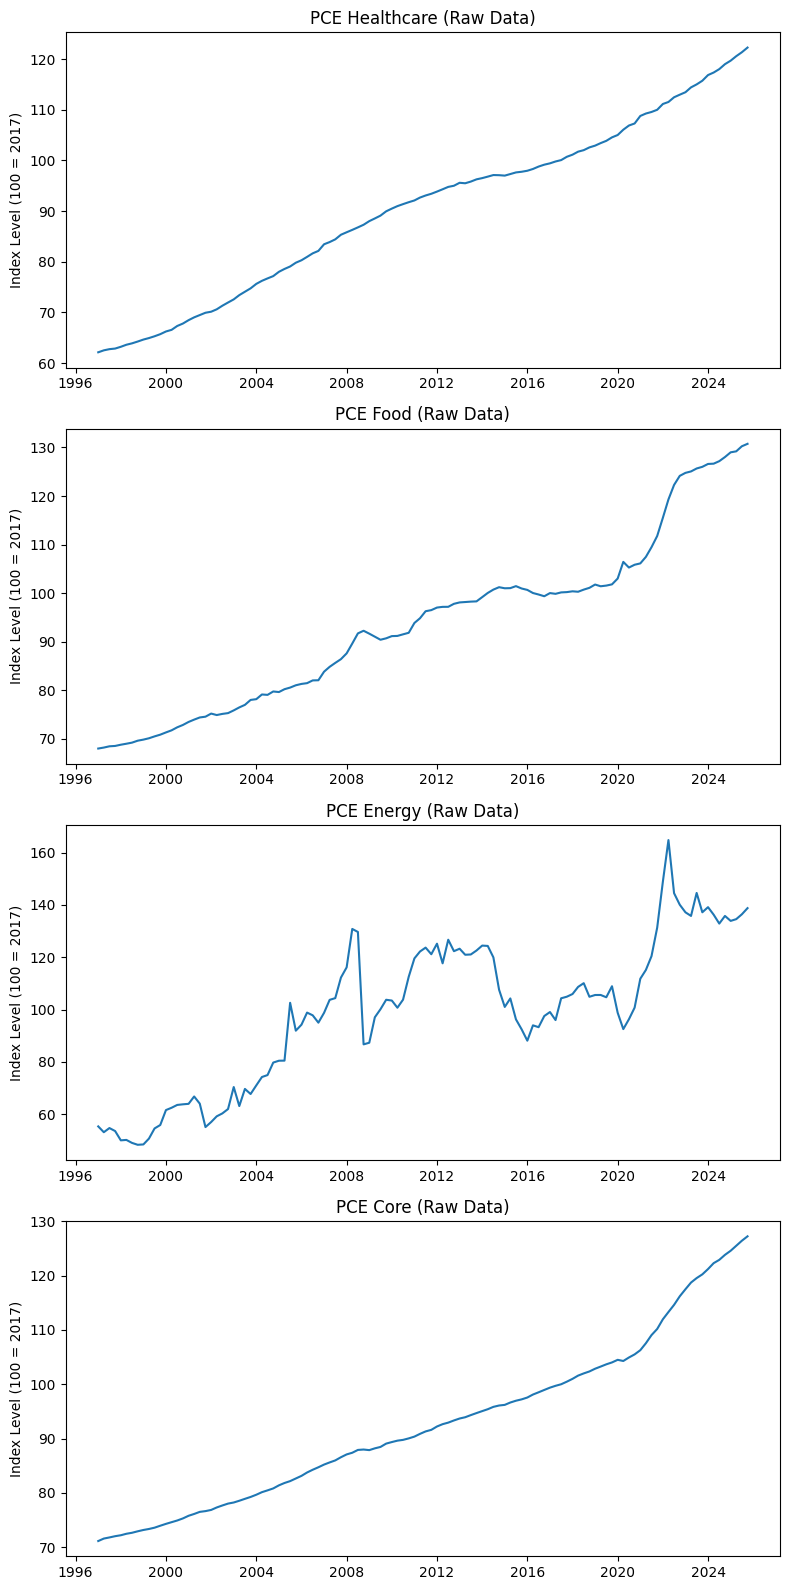

In [275]:
# PCE Visualization for Healthcare, Food, Energy and Core (RAW DATA)
raw_indicators = ['pce_health', 'pce_food', 'pce_energy', 'pce_core'] 

y_labels = ['Index Level (100 = 2017)', 'Index Level (100 = 2017)', 'Index Level (100 = 2017)', 'Index Level (100 = 2017)']
titles = ['PCE Healthcare (Raw Data)', 'PCE Food (Raw Data)', 'PCE Energy (Raw Data)', 'PCE Core (Raw Data)']

fig, axs = plt.subplots(len(raw_indicators), 1, figsize=(8, 4 * len(raw_indicators)))

for axes, col, y_label, title in zip(axs, raw_indicators, y_labels, titles):
    axes.plot(df_master.index, df_master[col])
    axes.set_title(title)
    axes.set_ylabel(y_label)

plt.tight_layout()
plt.show()

#### VIX and PERMIT Indicator Visualization

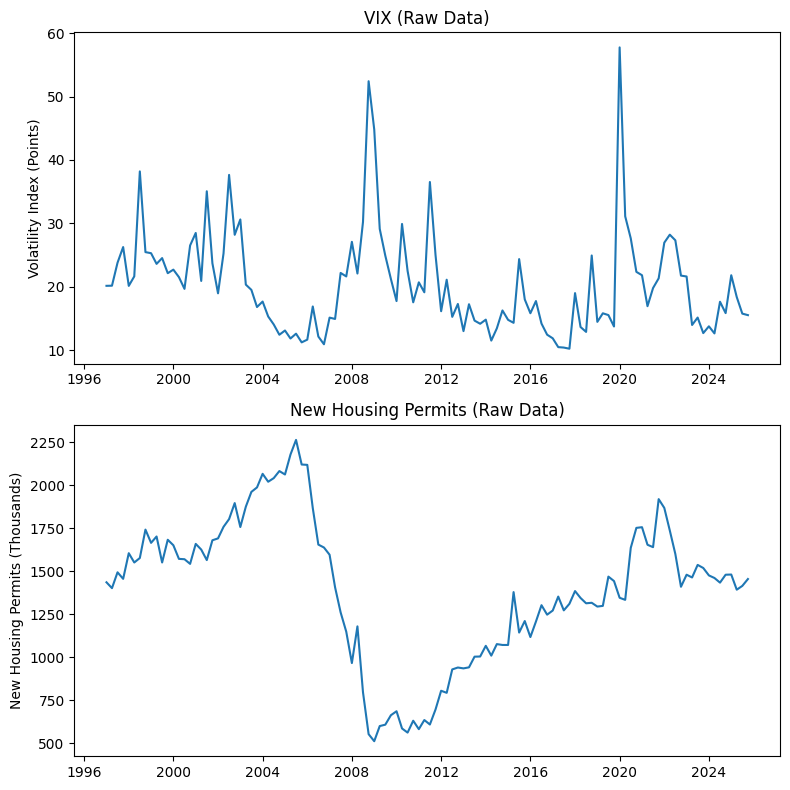

In [276]:
# Visualization for VIX and PERMIT
macro_indicators = ['vix', 'permit']
y_labels = ['Volatility Index (Points)', 'New Housing Permits (Thousands)']
titles   = ['VIX (Raw Data)', 'New Housing Permits (Raw Data)']

fig, axs = plt.subplots(len(macro_indicators), 1, figsize=(8, 4 * len(macro_indicators)))

for ax, col, y_label, title in zip(axs, macro_indicators, y_labels, titles):
    ax.plot(df_master.index, df_master[col])
    ax.set_title(title)
    ax.set_ylabel(y_label)

plt.tight_layout()
plt.show()

#### U6 Visualization

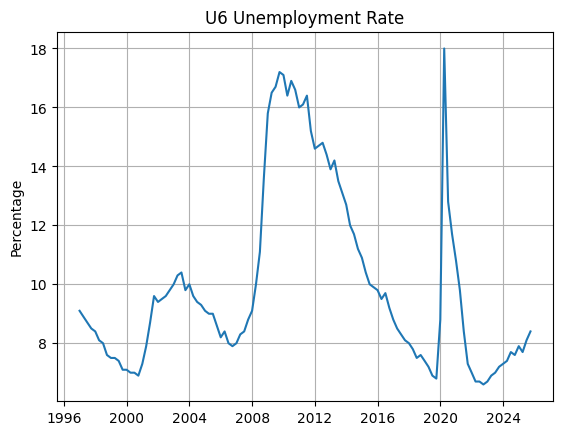

In [277]:
plt.plot(df_master.index, df_master['U6'])
plt.title('U6 Unemployment Rate')
plt.ylabel('Percentage')
plt.grid()
plt.show()

#### Raw PCE, VIX and PERMIT Summary Statistics 

In [278]:
# Grouping our raw columns together
raw_cols = {
    'PCE Healthcare'  : 'pce_health',
    'PCE Food'        : 'pce_food',
    'PCE Energy'      : 'pce_energy',
    'PCE Core'        : 'pce_core',
    'VIX'             : 'vix',
    'Housing Permits' : 'permit'
}

# Pull raw columns and compute summary stats
raw_df = df_master[list(raw_cols.values())]

# Renaming for clean display
raw_df.columns = list(raw_cols.keys())
raw_summary = raw_df.describe().loc[['mean', '50%', 'std', 'min', 'max']]
raw_summary.index = ['Mean', 'Median', 'Std Dev', 'Min', 'Max']
print("Summary Statistics - Raw Data:")
raw_summary.round(2)

Summary Statistics - Raw Data:


,PCE Healthcare,PCE Food,PCE Energy,PCE Core,VIX,Housing Permits
Mean,90.43,93.62,98.63,92.80,20.45,1391.82
Median,92.88,95.53,101.79,91.10,19.08,1449.00
Std Dev,16.90,17.46,28.37,15.07,8.08,418.74
Min,62.14,67.95,48.32,71.14,10.26,513.00
Max,122.27,130.76,164.76,127.24,57.74,2263.00


#### YOY % PCE Indicator Visualization

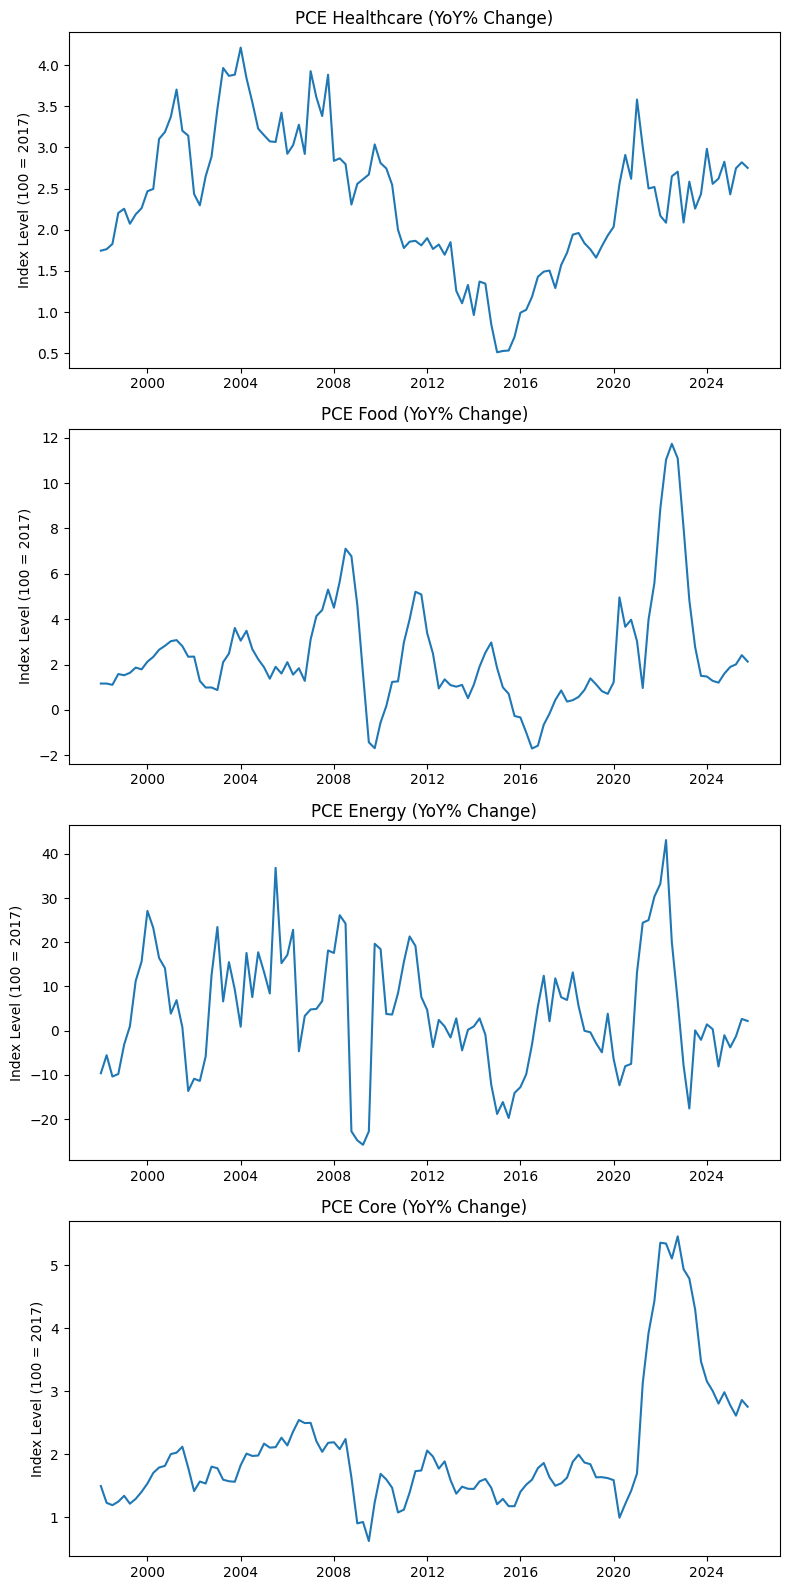

In [279]:
# PCE Visualization for Healthcare, Food, Energy and Core (YOY% Change)
yoy_indicators = ['pce_health_yoy', 'pce_food_yoy', 'pce_energy_yoy', 'pce_core_yoy'] 

y_labels = ['Index Level (100 = 2017)', 'Index Level (100 = 2017)', 'Index Level (100 = 2017)', 'Index Level (100 = 2017)']
titles = ['PCE Healthcare (YoY% Change)', 'PCE Food (YoY% Change)', 'PCE Energy (YoY% Change)', 'PCE Core (YoY% Change)']

fig, axs = plt.subplots(len(yoy_indicators), 1, figsize=(8, 4 * len(yoy_indicators)))

for axes, col, y_label, title in zip(axs, yoy_indicators, y_labels, titles):
    axes.plot(df_master.index, df_master[col])
    axes.set_title(title)
    axes.set_ylabel(y_label)

plt.tight_layout()
plt.show()

#### YOY% VIX and PERMIT Indicator Visualization

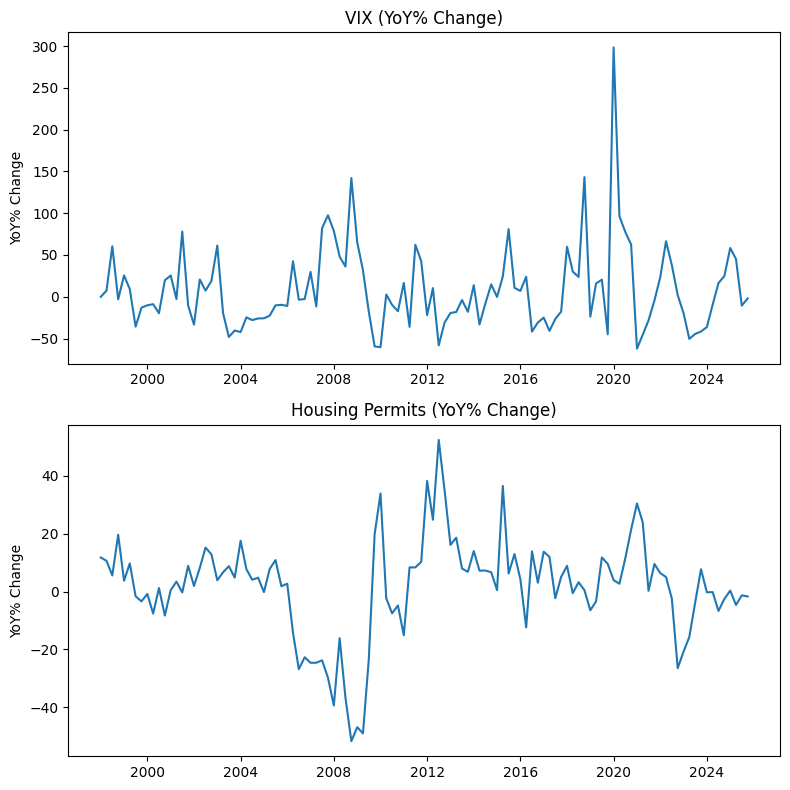

In [280]:
# VIX and Permit YoY% Change Visualization
macro_yoy_indicators = ['vix_yoy', 'permit_yoy']

y_labels = ['YoY% Change', 'YoY% Change']
titles   = ['VIX (YoY% Change)', 'Housing Permits (YoY% Change)']

fig, axs = plt.subplots(len(macro_yoy_indicators), 1, figsize=(8, 4 * len(macro_yoy_indicators)))

for axes, col, y_label, title in zip(axs, macro_yoy_indicators, y_labels, titles):
    axes.plot(df_master.index, df_master[col])
    axes.set_title(title)
    axes.set_ylabel(y_label)

plt.tight_layout()
plt.show()

#### YOY % PCE Summary Statistics 

In [281]:
# Group the base YoY columns together
yoy_cols = {
    'PCE Healthcare'  : 'pce_health_yoy',
    'PCE Food'        : 'pce_food_yoy',
    'PCE Energy'      : 'pce_energy_yoy',
    'PCE Core'        : 'pce_core_yoy',
    'VIX'             : 'vix_yoy',
    'Housing Permits' : 'permit_yoy'
}

# Pull just the YoY columns and compute summary stats
yoy_df = df_master[list(yoy_cols.values())]

# Rename for clean display
yoy_df.columns = list(yoy_cols.keys())

summary = yoy_df.describe().loc[['mean', '50%', 'std', 'min', 'max']]
summary.index = ['Mean', 'Median', 'Std Dev', 'Min', 'Max']

print("Summary Statistics — YoY % Change:")
summary.round(2)

Summary Statistics — YoY % Change:


,PCE Healthcare,PCE Food,PCE Energy,PCE Core,VIX,Housing Permits
Mean,2.39,2.35,4.22,2.04,8.20,1.62
Median,2.48,1.84,3.06,1.76,-2.91,3.82
Std Dev,0.84,2.40,13.62,0.99,49.99,17.18
Min,0.51,-1.70,-25.81,0.63,-62.18,-51.78
Max,4.21,11.73,43.12,5.46,298.48,52.46


#### Correlation Matrix + Heatmap (PCE Indicators)

Shape after dropping NaNs: (104, 34)
PCE lagged columns: ['pce_health_yoy_6m', 'pce_health_yoy_1y', 'pce_health_yoy_2y', 'pce_food_yoy_6m', 'pce_food_yoy_1y', 'pce_food_yoy_2y', 'pce_energy_yoy_6m', 'pce_energy_yoy_1y', 'pce_energy_yoy_2y', 'pce_core_yoy_6m', 'pce_core_yoy_1y', 'pce_core_yoy_2y']
Delinquency columns: ['ccard_dr', 'csm_loan_dr', 'mtg_dr']


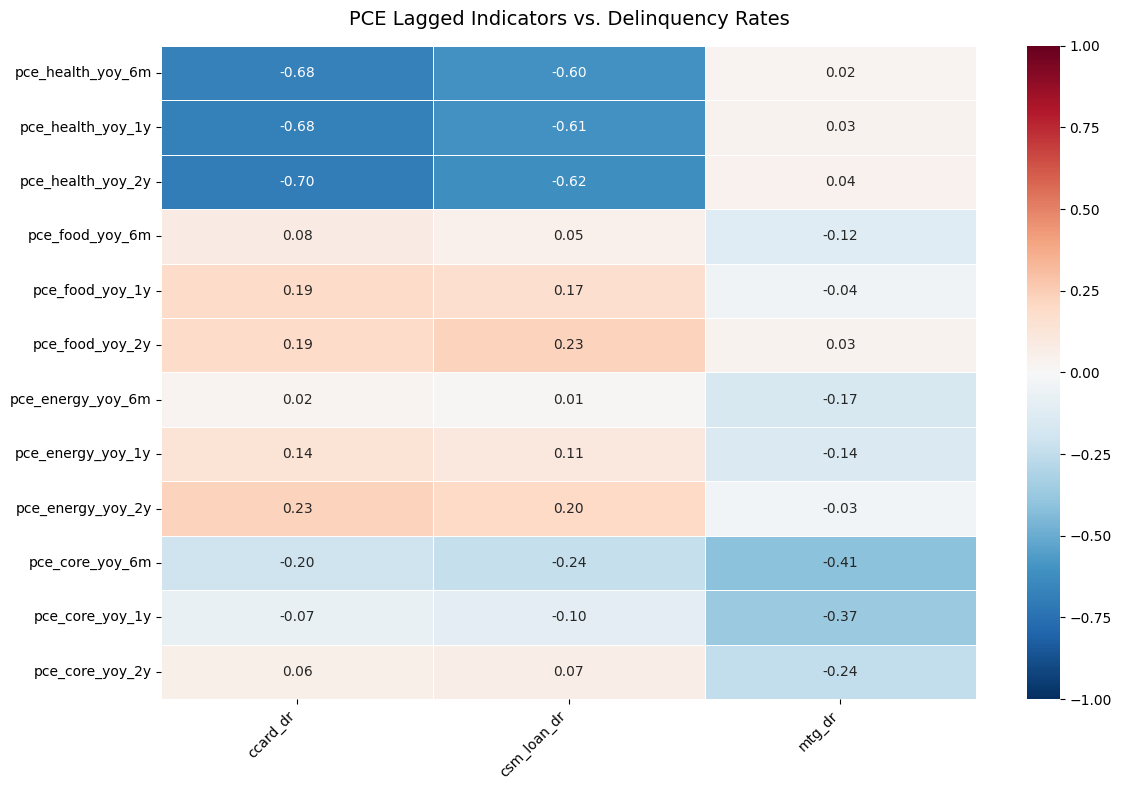

In [282]:
# Generating a correlation matrix to observe the data
df_master = df_master.dropna()
print(f"Shape after dropping NaNs: {df_master.shape}")
# Need to remove the new NaN rows initially created

# The lagged PCE columns you want to test
pce_lagged_cols = [
    'pce_health_yoy_6m', 'pce_health_yoy_1y', 'pce_health_yoy_2y',
    'pce_food_yoy_6m',   'pce_food_yoy_1y',   'pce_food_yoy_2y',
    'pce_energy_yoy_6m', 'pce_energy_yoy_1y', 'pce_energy_yoy_2y',
    'pce_core_yoy_6m',   'pce_core_yoy_1y',   'pce_core_yoy_2y',
]

# The three delinquency rate columns
delinq_cols = ['ccard_dr', 'csm_loan_dr', 'mtg_dr']

print("PCE lagged columns:", pce_lagged_cols)
print("Delinquency columns:", delinq_cols) 

# Combining both groups and compute correlation
all_cols = pce_lagged_cols + delinq_cols
corr_matrix = df_master[all_cols].corr(method='pearson')
corr_matrix.round(2)

# Rows will be the PCE lagged indicators, Columns is the delinquency rates
focused_corr = corr_matrix.loc[pce_lagged_cols, delinq_cols]
focused_corr.round(2)

# Displaying heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    focused_corr,        # Sliced matrix from Cell 4
    annot=True,          # Show the numbers inside each cell
    fmt='.2f',           # Round each num to 2 decimal places
    cmap='RdBu_r',       # Red = positive, Blue = negative
    vmin=-1, vmax=1,     # Fix the color scale
    linewidths=0.5
)

plt.title('PCE Lagged Indicators vs. Delinquency Rates', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Correlation Matrix + Heatmap (VIX and Housing Permit)

Macro lagged columns: ['vix_6m', 'vix_1y', 'vix_2y', 'permit_yoy_6m', 'permit_yoy_1y', 'permit_yoy_2y']


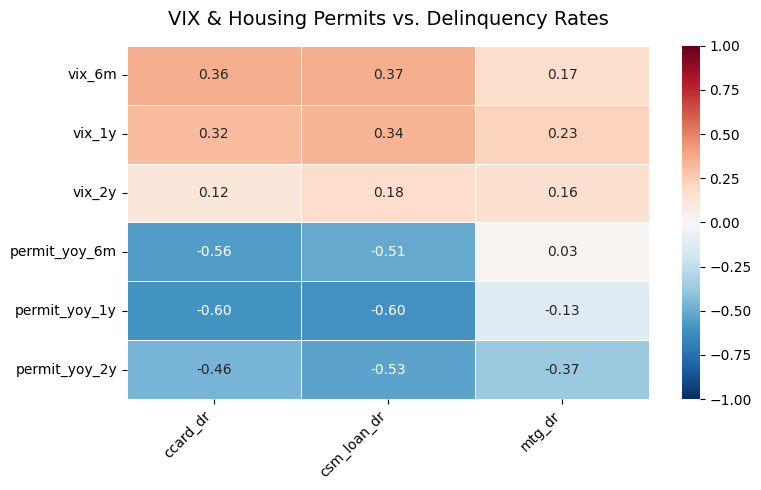

In [283]:
# The lagged macro columns for VIX and Housing Permit
macro_lagged_cols = [
    'vix_6m', 'vix_1y', 'vix_2y',
    'permit_yoy_6m', 'permit_yoy_1y', 'permit_yoy_2y'
]

print("Macro lagged columns:", macro_lagged_cols)

# Combining macro and delinquency cols and compute correlation
macro_all_cols = macro_lagged_cols + delinq_cols
macro_corr_matrix = df_master[macro_all_cols].corr(method='pearson')

# Rows = macro lagged indicators, Columns = delinquency rates
macro_focused_corr = macro_corr_matrix.loc[macro_lagged_cols, delinq_cols]
macro_focused_corr.round(2)

# Displaying heatmap
plt.figure(figsize=(8, 5))

sns.heatmap(
    macro_focused_corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    linewidths=0.5
)

plt.title('VIX & Housing Permits vs. Delinquency Rates', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Advanced Correlation Analysis

##### In this section, we will mainly use the datasets that have the best lag indicator. We will also build a logistic and linear regression model to better analyze and project the correlations

In [ ]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

## Findings

## Conclusion